In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import tensorflow as tf

* Read The Dataset

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* EDA

In [3]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')


In [4]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# stats
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Check Nans
df.isna().sum(axis=0).sort_values(ascending=False)

,0
cabin,687
age,177
embarked,2
passengerid,0
name,0
pclass,0
survived,0
sex,0
parch,0
sibsp,0


### Viz

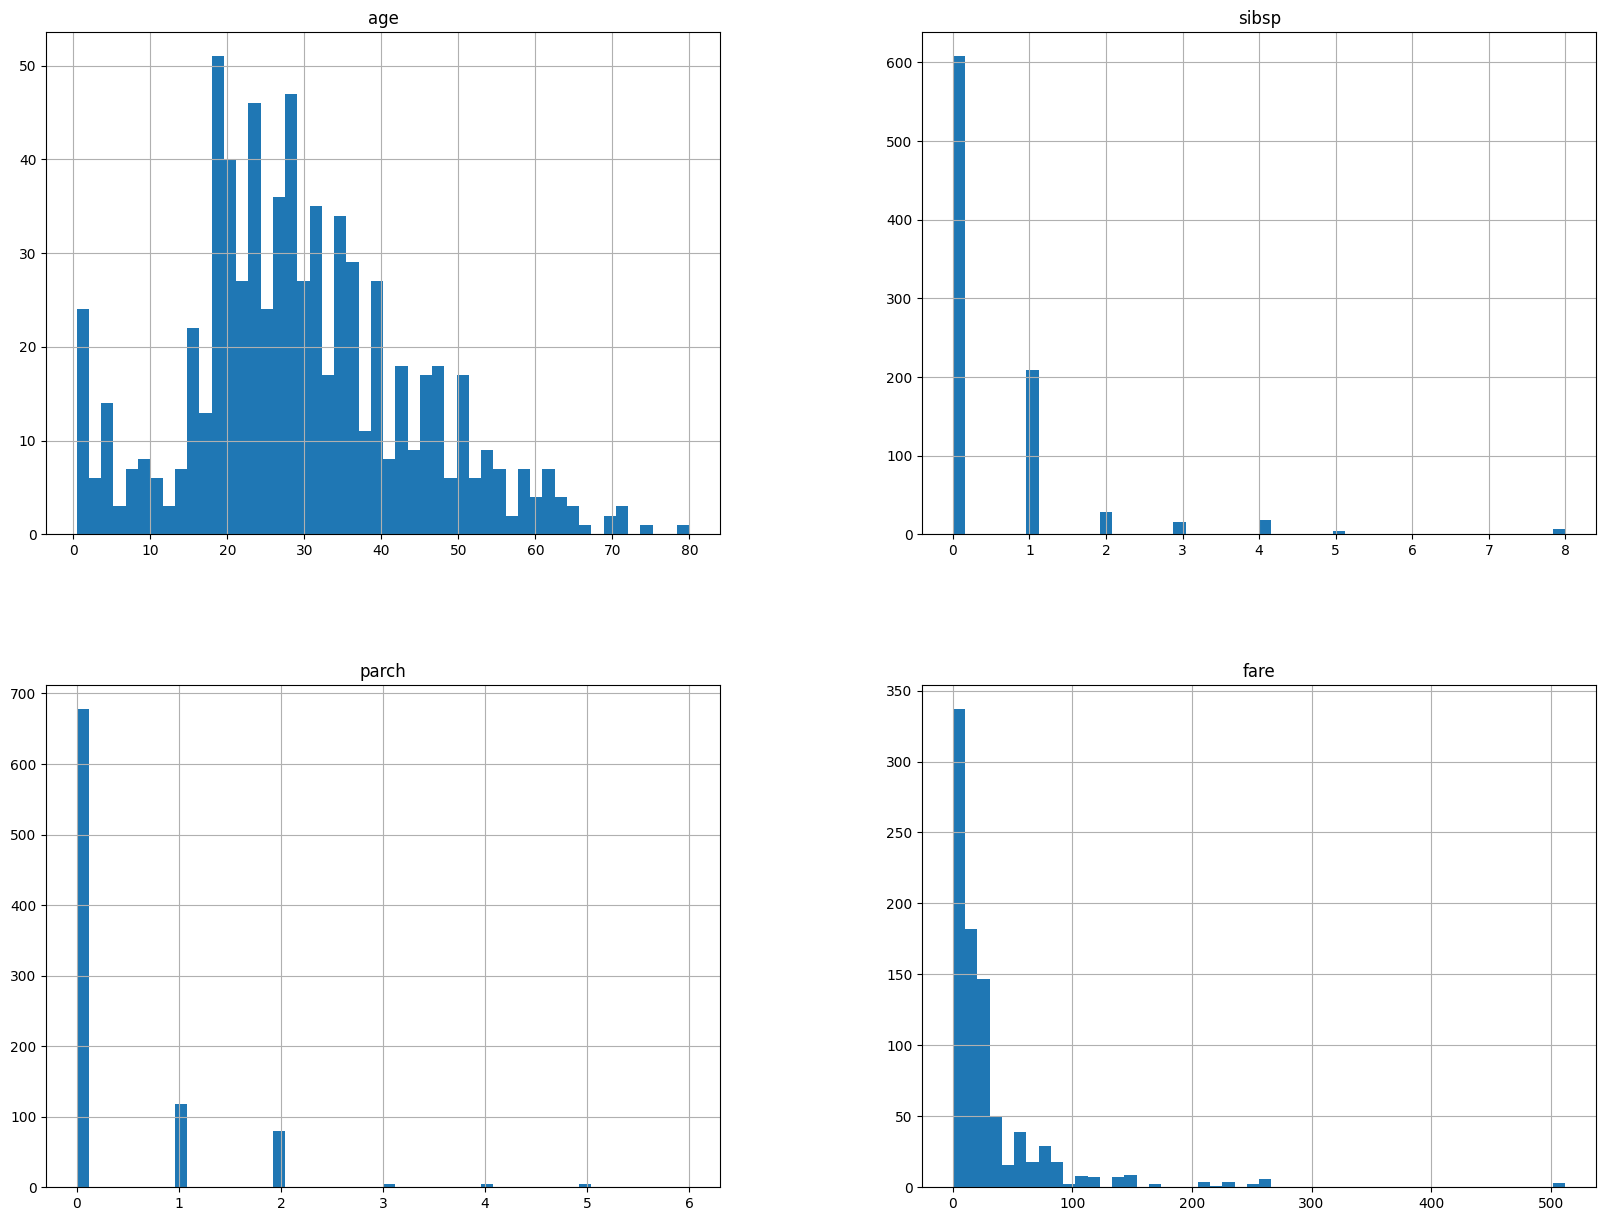

In [8]:
num_cols = ['age', 'sibsp', 'parch', 'fare']
df[num_cols].hist(bins=50, figsize=(20, 15))
plt.show()

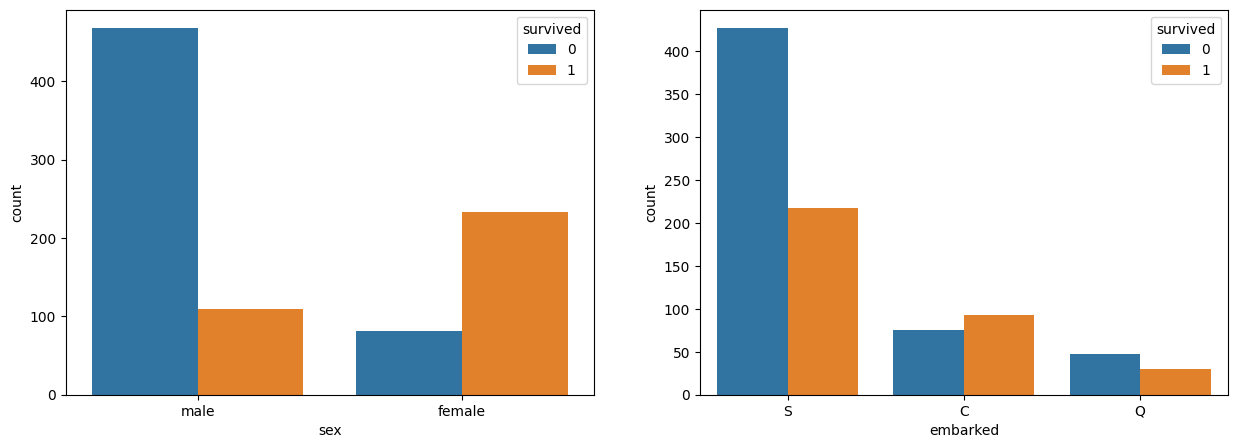

In [9]:
# Categorical Cols
categ_cols = ['sex', 'embarked']
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for idx, col in enumerate(categ_cols):
    sns.countplot(data=df, x=col, ax=ax[idx], hue='survived')

plt.show()

## Feature Engineering

In [10]:
# Add One To Count The Passengers Themselves
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Check If He Is Alone Or Not
def is_alone(x):
  if x > 1:
    return 0
  else:
    return 1

df['is_alone'] = df['family_size'].apply(is_alone)

In [11]:
# Check
df[['sibsp', 'parch', 'family_size', 'is_alone']].head()

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Split The Dataset

In [12]:
# Split To X & y
choosen_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']
X = df[choosen_features]
y = df['survived']

# To Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 9), (179, 9), (712,), (179,))

## Preprocessing

In [14]:
# Slice Cols
num_cols = ['age', 'fare']
categ_cols = ['sex', 'embarked']
ready_cols = list(set(X_train.columns) - set(num_cols) - set(categ_cols))
num_cols, categ_cols, ready_cols

(['age', 'fare'],
 ['sex', 'embarked'],
 ['pclass', 'sibsp', 'family_size', 'parch', 'is_alone'])

In [15]:
# Pipeline

# Num Pipeline
num_pipeline = Pipeline([
    ('imbuter', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categ_pipeline = Pipeline([
    ('imbuter', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])

# Ready Pipeline

ready_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine All
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('categ', categ_pipeline, categ_cols),
    ('ready', ready_pipeline, ready_cols)
])

# Apply
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [16]:
X_train_final.shape, X_test_final.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [17]:
# Dump Pipeline
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), 'models')
os.makedirs(MODELS_FOLDER_PATH, exist_ok = True)
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.joblib'))

['/content/models/preprocessor.joblib']

### Build Nueral Network

In [18]:
X_train.shape

(712, 9)

In [19]:
# Build Basic NN Model
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Categorical_crossentropy -> (Multi Class Target) Must Be OHE
# crossentropy -> (Multi Class Target)
# Binary_crossentropy
# Sparse_Categorical_crossentropy

In [21]:
# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    metrics=['accuracy']
)

# fit
history = model.fit(X_train_final, y_train,
                    epochs=100, batch_size=32
                    , validation_split=0.2)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5817 - loss: 0.6769 - val_accuracy: 0.6434 - val_loss: 0.6259
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6696 - loss: 0.5984 - val_accuracy: 0.6993 - val_loss: 0.5868
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7100 - loss: 0.5552 - val_accuracy: 0.7343 - val_loss: 0.5516
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7434 - loss: 0.5190 - val_accuracy: 0.7622 - val_loss: 0.5097
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7926 - loss: 0.4856 - val_accuracy: 0.8042 - val_loss: 0.4775
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7926 - loss: 0.4615 - val_accuracy: 0.7972 - val_loss: 0.4687
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7996 - loss: 0.4501 - val_accuracy: 0.8112 - val_loss: 0.4583
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8067 - loss: 0.4399 - val_accuracy: 0.8042 -

In [22]:
test_loss, test_acc = model.evaluate(X_test_final, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7821 - loss: 0.5925


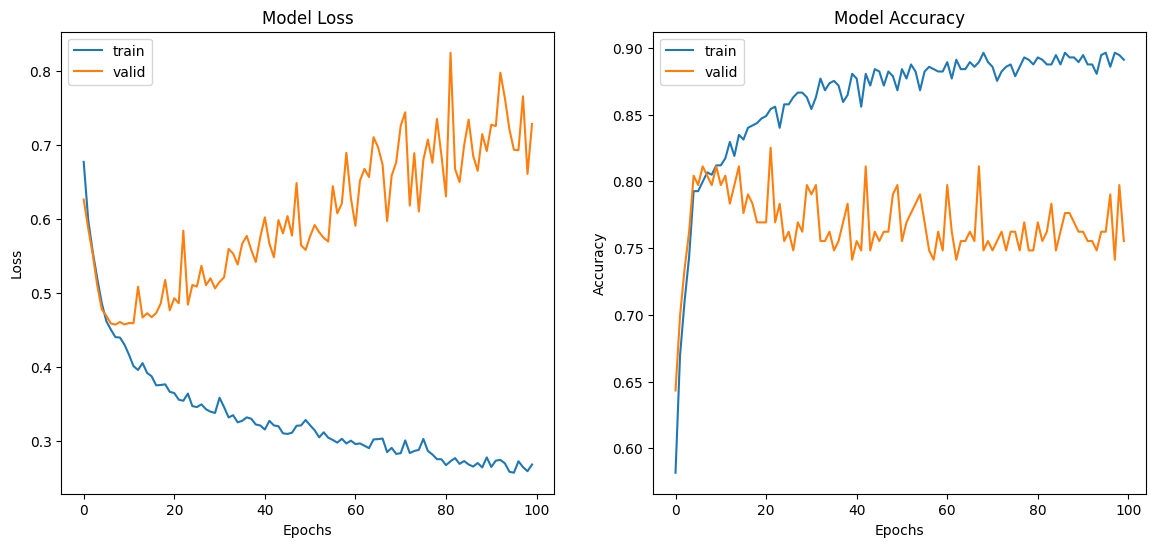

In [23]:
# Vizualization History
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## Enhancing The Model

In [24]:
# Dropout
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5, seed=97),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    metrics=['accuracy']
)

# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# fit
history = model.fit(X_train_final, y_train,
                    epochs=100, batch_size=32
                    , validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - accuracy: 0.5712 - loss: 0.7017 - val_accuracy: 0.6014 - val_loss: 0.6556
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6274 - loss: 0.6739 - val_accuracy: 0.6993 - val_loss: 0.6530
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5958 - loss: 0.6564 - val_accuracy: 0.6713 - val_loss: 0.6334
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6327 - loss: 0.6424 - val_accuracy: 0.6713 - val_loss: 0.6226
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6415 - loss: 0.6167 - val_accuracy: 0.6993 - val_loss: 0.6124
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6467 - loss: 0.6096 - val_accuracy: 0.7273 - val_loss: 0.6072
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6591 - loss: 0.6207 - val_accuracy: 0.7343 - val_loss: 0.5990
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6766 - loss: 0.5692 - val_accuracy: 0.7273 -

In [26]:
test_loss, test_acc = model.evaluate(X_test_final, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8156 - loss: 0.4478


In [27]:
## OR pd.DataFrame(history.history).plot

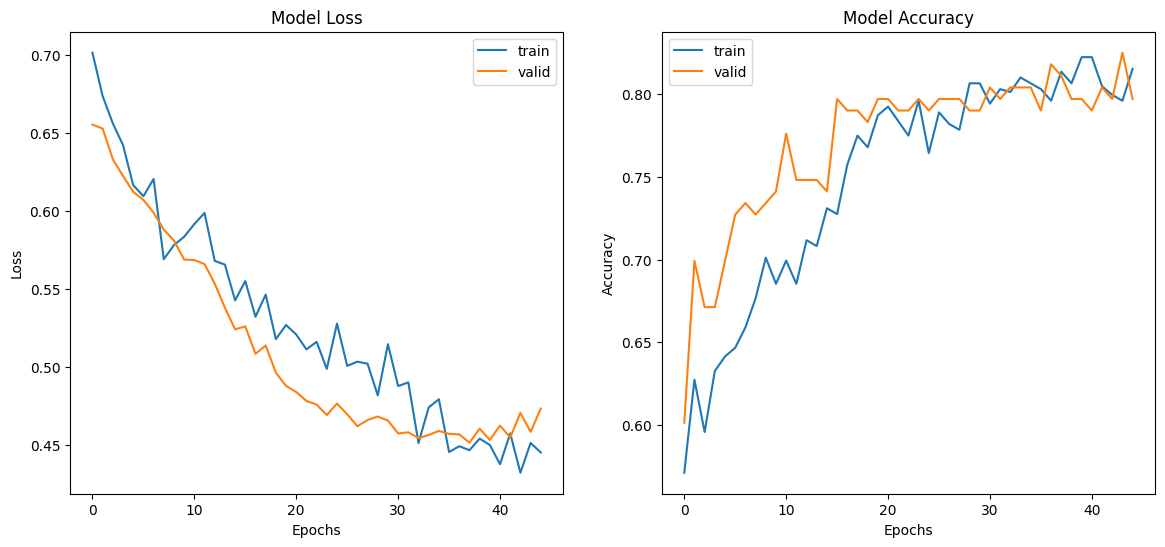

In [28]:
# Vizualization History
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

### Using L2 Norm Regulizer

In [29]:
# L2
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    metrics=['accuracy']
)

# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# fit
history = model.fit(X_train_final, y_train,
                    epochs=100, batch_size=32
                    , validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.6257 - loss: 1.9797 - val_accuracy: 0.6294 - val_loss: 1.8041
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6766 - loss: 1.6597 - val_accuracy: 0.6923 - val_loss: 1.5277
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 1.4101 - val_accuracy: 0.7063 - val_loss: 1.3140
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7417 - loss: 1.2206 - val_accuracy: 0.7413 - val_loss: 1.1490
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7540 - loss: 1.0684 - val_accuracy: 0.7762 - val_loss: 1.0123
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7786 - loss: 0.9530 - val_accuracy: 0.7552 - val_loss: 0.9073
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7856 - loss: 0.8560 - val_accuracy: 0.7972 - val_loss: 0.8220
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7961 - loss: 0.7862 - val_accuracy: 0.7972 -

In [31]:
test_loss, test_acc = model.evaluate(X_test_final, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8045 - loss: 0.5241


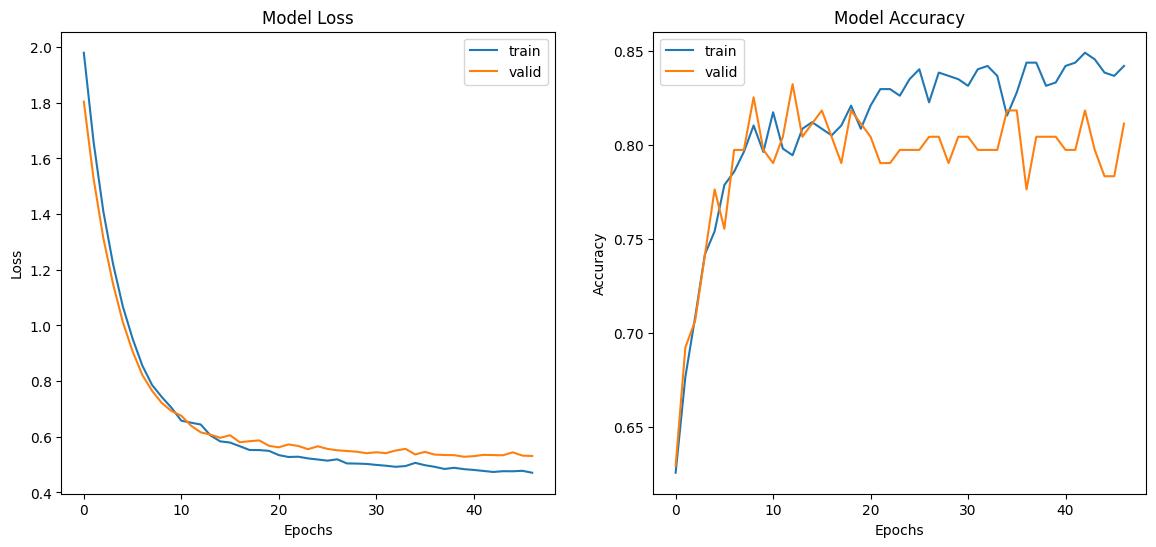

In [32]:
# Vizualization History
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(ax[0])
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.sca(ax[1])
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## Tuning

In [33]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.8 MB/s eta 0:00:00


In [34]:
def build_model(hp):
  model = tf.keras.Sequential([

    # Input Layer
    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),

    # 1st Layer
    tf.keras.layers.Dense(units=hp.Int("units_1", min_value=32, max_value=256, step=32), activation='relu'),

    # Dropout
    tf.keras.layers.Dropout(hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)),

    # 2nd Layer
    tf.keras.layers.Dense(units=hp.Int("units_2", min_value=32, max_value=256, step=32), activation='relu'),

    # Dropout
    tf.keras.layers.Dropout(hp.Float("dropout_2", min_value=0.0, max_value=0.5, step=0.1)),

    # output Layer
    tf.keras.layers.Dense(1, activation='sigmoid')

  ])

  # Compile
  model.compile(
      loss='binary_crossentropy',
      optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
      metrics=['accuracy']
  )

  return model



In [35]:
# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


In [36]:
from kerastuner import RandomSearch

/tmp/ipykernel_1108/659161079.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


In [38]:
tuner =  RandomSearch(
          hypermodel=build_model,
          objective='val_accuracy',
          max_trials=10,
          seed=174,
          directory="random_search_dir",
          project_name='random_search',
          max_retries_per_trial=2

          )

In [39]:
# running
tuner.search(X_train_final, y_train,
             epochs=50, validation_split=0.2,
             callbacks=[early_stop])

Trial 10 Complete [00h 00m 08s]
val_accuracy: 0.8251748085021973

Best val_accuracy So Far: 0.8321678042411804
Total elapsed time: 00h 02m 27s


In [41]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential, built=True>

In [43]:
test_loss, test_acc = model.evaluate(X_test_final, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8045 - loss: 0.5241


---

In [44]:
# Save Model
best_model.save(os.path.join(MODELS_FOLDER_PATH, 'best_model.keras'))

## Load Model

In [46]:
model = tf.keras.models.load_model(os.path.join(MODELS_FOLDER_PATH, "best_model.keras"))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 224)            │         2,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,093 (113.65 KB)

 Trainable params: 9,697 (37.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,396 (75.77 KB)

In [48]:
samples = df.sample(10, random_state=14)

In [50]:
samples_processed = preprocessor.transform(samples)

In [53]:
predictions = (model.predict(samples_processed) > 0.5).astype('int32')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [54]:
pd.DataFrame({
    'PassengerId': samples['passengerid'],
    'Predicted': ['Survived' if pred == 1 else 'Not Survived' for pred in predictions.flatten()]
})

,PassengerId,Predicted
75,76,Not Survived
602,603,Not Survived
119,120,Not Survived
647,648,Not Survived
115,116,Not Survived
472,473,Survived
547,548,Not Survived
735,736,Not Survived
467,468,Not Survived
759,760,Survived
